# Dataset Evaluation

This notebook evaluates three registration strategies across the full 18-pair brain MR dataset:

| Strategy | Description |
|----------|-------------|
| **A** | Gradient ascent (GA) from identity initialisation (baseline) |
| **B** | Principal Axes Transform (PAT) standalone - no optimisation |
| **C** | PAT initialisation followed by GA refinement |

For both **T1→T1d** (intra-modal) pairs and **T1→T2** (inter-modal) pairs we use **NCC** (rigid_corr)

---
## Section 1 — Imports and shared function definitions

In [69]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../code')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import registration as reg
import registration_util as util
import PAT_util as pat

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [70]:
# Shared constants
N_ITERATIONS  = 500
LEARNING_RATE = 1e-3
PATIENTS      = [1, 2, 3]
SLICES        = [1, 2, 3]
DATA_DIR      = '../data/'
SCALING       = 100   # must match the constant inside rigid_corr

In [71]:
"""
# -- rigid_mi --
# Builds the rigid Th from x = [angle, tx_scaled, ty_scaled] using the same
# convention as rigid_corr (SCALING applied to translation), then returns MI.
def rigid_mi(I, J, x):
    T   = reg.rotate(x[0])
    Th  = util.t2h(T, x[1:] * SCALING)
    J_t, _ = reg.image_transform(J, Th)
    p   = reg.joint_histogram(I, J_t)
    return reg.mutual_information(p)
    
"""

'\n# -- rigid_mi --\n# Builds the rigid Th from x = [angle, tx_scaled, ty_scaled] using the same\n# convention as rigid_corr (SCALING applied to translation), then returns MI.\ndef rigid_mi(I, J, x):\n    T   = reg.rotate(x[0])\n    Th  = util.t2h(T, x[1:] * SCALING)\n    J_t, _ = reg.image_transform(J, Th)\n    p   = reg.joint_histogram(I, J_t)\n    return reg.mutual_information(p)\n    \n'

---
## Section 2 — Build the dataset of image pairs

Eighteen pairs total: for each patient (1–3) and slice (1–3), one intra-modal T1→T1d pair and one inter-modal T1→T2 pair. The fixed image is always the T1 scan.

In [72]:
def load_image(patient_id, slice_id, sequence):
    """Load a .tif image and return it as a float64 array."""
    path = f'{DATA_DIR}image_data/{patient_id}_{slice_id}_{sequence}.tif'
    return plt.imread(path).astype(np.float64)


all_pairs = []
for patient_id in PATIENTS:
    for slice_id in SLICES:
        fixed = load_image(patient_id, slice_id, 't1')

        # T1 -> T1d (intra-modal)
        all_pairs.append({
            'pair_id':    f'P{patient_id}_S{slice_id}_T1T1d',
            'patient_id': patient_id,
            'slice_id':   slice_id,
            'modality':   'T1-T1d',
            'fixed':      fixed,
            'moving':     load_image(patient_id, slice_id, 't1_d'),
        })

        # T1 -> T2 (inter-modal)
        all_pairs.append({
            'pair_id':    f'P{patient_id}_S{slice_id}_T1T2',
            'patient_id': patient_id,
            'slice_id':   slice_id,
            'modality':   'T1-T2',
            'fixed':      fixed,
            'moving':     load_image(patient_id, slice_id, 't2'),
        })


# Table
print(f'{"pair_id":<25} {"modality":<10} {"fixed":<22} {"moving"}')
print('-' * 88)
for p in all_pairs:
    seq_m = 't1_d' if p['modality'] == 'T1-T1d' else 't2'
    fname = f'{p["patient_id"]}_{p["slice_id"]}_t1.tif'
    mname = f'{p["patient_id"]}_{p["slice_id"]}_{seq_m}.tif'
    print(f'{p["pair_id"]:<25} {p["modality"]:<10} {fname:<22} {mname}')
print(f'\nTotal pairs: {len(all_pairs)}')

pair_id                   modality   fixed                  moving
----------------------------------------------------------------------------------------
P1_S1_T1T1d               T1-T1d     1_1_t1.tif             1_1_t1_d.tif
P1_S1_T1T2                T1-T2      1_1_t1.tif             1_1_t2.tif
P1_S2_T1T1d               T1-T1d     1_2_t1.tif             1_2_t1_d.tif
P1_S2_T1T2                T1-T2      1_2_t1.tif             1_2_t2.tif
P1_S3_T1T1d               T1-T1d     1_3_t1.tif             1_3_t1_d.tif
P1_S3_T1T2                T1-T2      1_3_t1.tif             1_3_t2.tif
P2_S1_T1T1d               T1-T1d     2_1_t1.tif             2_1_t1_d.tif
P2_S1_T1T2                T1-T2      2_1_t1.tif             2_1_t2.tif
P2_S2_T1T1d               T1-T1d     2_2_t1.tif             2_2_t1_d.tif
P2_S2_T1T2                T1-T2      2_2_t1.tif             2_2_t2.tif
P2_S3_T1T1d               T1-T1d     2_3_t1.tif             2_3_t1_d.tif
P2_S3_T1T2                T1-T2      2_3_t1.tif    

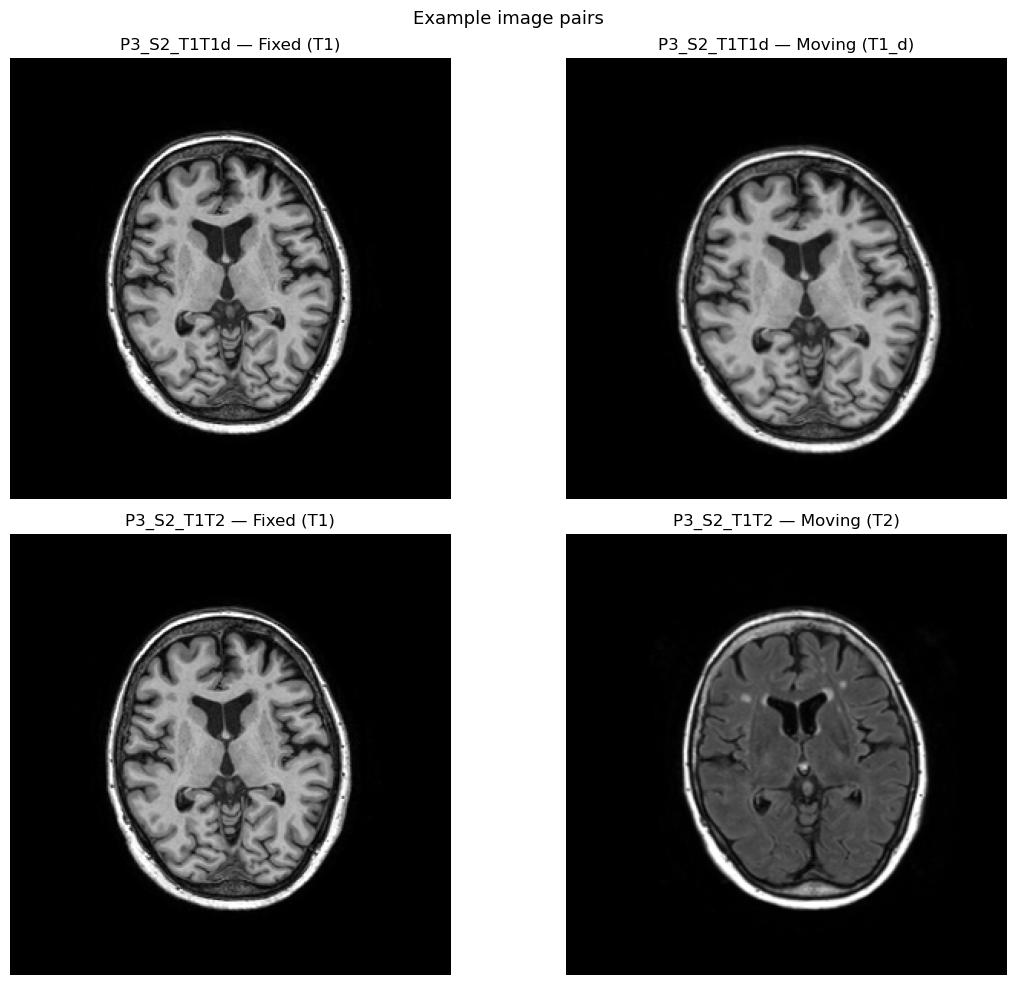

In [73]:
# Display one example from each modality (patient 3, slice 2)
ex_t1t1d = all_pairs[14]   # P3_S2_T1T1d
ex_t1t2  = all_pairs[15]   # P3_S2_T1T2

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for row, pair in enumerate([ex_t1t1d, ex_t1t2]):
    axes[row, 0].imshow(pair['fixed'], cmap='gray')
    axes[row, 0].set_title(f'{pair["pair_id"]} — Fixed (T1)')
    axes[row, 0].axis('off')

    seq_m_label = 'T1_d' if pair['modality'] == 'T1-T1d' else 'T2'
    axes[row, 1].imshow(pair['moving'], cmap='gray')
    axes[row, 1].set_title(f'{pair["pair_id"]} — Moving ({seq_m_label})')
    axes[row, 1].axis('off')

plt.suptitle('Example image pairs', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 3 — Evaluation loop

For each of the 18 pairs we run all three strategies and record NCC, MI, and convergence iteration. 

In [74]:
def convergence_iter(history, threshold=1e-5):
    """First iteration where |history[i]-history[i-1]| < threshold, else N_ITERATIONS."""
    for i in range(1, len(history)):
        if abs(history[i] - history[i - 1]) < threshold:
            return i
    return len(history)


def run_all_strategies(pairs, n_iterations, learning_rate):
    records     = []
    images_dict = {}

    for pair in pairs:
        pair_id    = pair['pair_id']
        patient_id = pair['patient_id']
        slice_id   = pair['slice_id']
        modality   = pair['modality']
        fixed      = pair['fixed']
        moving     = pair['moving']

        """
        if modality == 'T1-T1d':
            sim_fn = lambda x, f=fixed, m=moving: reg.rigid_corr(f, m, x, return_transform=False)
        else:
            sim_fn = lambda x, f=fixed, m=moving: rigid_mi(f, m, x)
        """

        sim_fn = lambda x, f=fixed, m=moving: reg.rigid_corr(f, m, x, return_transform=False)

        ncc_before = reg.correlation(fixed, moving)
        mi_before  = reg.mutual_information(reg.joint_histogram(fixed, moving))

        print(f'\n=== {pair_id} ({modality}) ===')

        # -- Strategy A: identity init --
        print('Strategy A:')
        x_init_a        = np.array([0.0, 0.0, 0.0])
        x_opt_a, hist_a = pat.gradient_ascent_registration(
            fixed, moving, x_init_a, sim_fn, n_iterations, learning_rate)
        Th_a            = pat.params_to_Th(x_opt_a)
        J_reg_a, _      = reg.image_transform(moving, Th_a)
        ncc_a           = reg.correlation(fixed, J_reg_a)
        mi_a            = reg.mutual_information(reg.joint_histogram(fixed, J_reg_a))
        conv_a          = convergence_iter(hist_a)
        images_dict[(pair_id, 'A')] = J_reg_a

        # -- Strategy B: PAT standalone --
        print('Strategy B:')
        Th_b            = pat.principal_axes_transform(fixed, moving)
        J_reg_b, _      = reg.image_transform(moving, Th_b)
        ncc_b           = reg.correlation(fixed, J_reg_b)
        mi_b            = reg.mutual_information(reg.joint_histogram(fixed, J_reg_b))
        angle_b         = np.arctan2(Th_b[1, 0], Th_b[0, 0])
        tx_b            = Th_b[0, 2] / SCALING
        ty_b            = Th_b[1, 2] / SCALING
        images_dict[(pair_id, 'B')] = J_reg_b

        # -- Strategy C: PAT init + gradient ascent --
        print('Strategy C:')
        x_init_c        = np.array([angle_b, tx_b, ty_b])
        x_opt_c, hist_c = pat.gradient_ascent_registration(
            fixed, moving, x_init_c, sim_fn, n_iterations, learning_rate)
        Th_c            = pat.params_to_Th(x_opt_c)
        J_reg_c, _      = reg.image_transform(moving, Th_c)
        ncc_c           = reg.correlation(fixed, J_reg_c)
        mi_c            = reg.mutual_information(reg.joint_histogram(fixed, J_reg_c))
        conv_c          = convergence_iter(hist_c)
        images_dict[(pair_id, 'C')] = J_reg_c

        for strat, ncc_val, mi_val, conv_val in [
            ('A', ncc_a, mi_a, conv_a),
            ('B', ncc_b, mi_b, 0),
            ('C', ncc_c, mi_c, conv_c),
        ]:
            records.append({
                'pair_id':                pair_id,
                'patient_id':             patient_id,
                'slice_id':               slice_id,
                'modality':               modality,
                'strategy':               strat,
                'ncc_before':             ncc_before,
                'ncc_after':              ncc_val,
                'mi_before':              mi_before,
                'mi_after':               mi_val,
                'converged_at_iteration': conv_val,
            })

        print(f'Done: {pair_id} | NCC  A={ncc_a:.4f}  B={ncc_b:.4f}  C={ncc_c:.4f}')

    return pd.DataFrame(records), images_dict

In [75]:
results, images_dict = run_all_strategies(all_pairs, N_ITERATIONS, LEARNING_RATE)
print(f'\nResults shape: {results.shape}')
display(results)


=== P1_S1_T1T1d (T1-T1d) ===
Strategy A:
  Initial similarity : 1.0000
  Initial parameters : angle=0.00 deg, tx=0.0000, ty=0.0000
  Final similarity   : 0.9767
  Final parameters   : angle=0.08 deg, tx=-0.0048, ty=0.0041
Strategy B:
Rotation angle: 0.0000 rad  (0.00 deg)
Strategy C:
  Initial similarity : 1.0000
  Initial parameters : angle=0.00 deg, tx=0.0000, ty=0.0000
  Final similarity   : 0.9767
  Final parameters   : angle=0.08 deg, tx=-0.0048, ty=0.0041
Done: P1_S1_T1T1d | NCC  A=0.9767  B=1.0000  C=0.9767

=== P1_S1_T1T2 (T1-T2) ===
Strategy A:
  Initial similarity : 0.5253
  Initial parameters : angle=0.00 deg, tx=0.0000, ty=0.0000
  Final similarity   : 0.8793
  Final parameters   : angle=3.21 deg, tx=0.0258, ty=0.0725
Strategy B:
Rotation angle: -0.0581 rad  (-3.33 deg)
Strategy C:
  Initial similarity : 0.8599
  Initial parameters : angle=3.33 deg, tx=0.0321, ty=0.0807
  Final similarity   : 0.8793
  Final parameters   : angle=3.21 deg, tx=0.0258, ty=0.0725
Done: P1_S1_T1

,pair_id,patient_id,slice_id,modality,strategy,ncc_before,ncc_after,mi_before,mi_after,converged_at_iteration
0,P1_S1_T1T1d,1,1,T1-T1d,A,1.000000,0.976681,1.477841,0.906454,1
1,P1_S1_T1T1d,1,1,T1-T1d,B,1.000000,1.000000,1.477841,1.477841,0
2,P1_S1_T1T1d,1,1,T1-T1d,C,1.000000,0.976681,1.477841,0.906454,1
3,P1_S1_T1T2,1,1,T1-T2,A,0.525290,0.879287,0.425117,0.742357,45
4,P1_S1_T1T2,1,1,T1-T2,B,0.525290,0.859899,0.425117,0.697795,0
5,P1_S1_T1T2,1,1,T1-T2,C,0.525290,0.879287,0.425117,0.742332,11
6,P1_S2_T1T1d,1,2,T1-T1d,A,0.673867,0.952751,0.451677,0.803841,135
7,P1_S2_T1T1d,1,2,T1-T1d,B,0.673867,0.918085,0.451677,0.694650,0
8,P1_S2_T1T1d,1,2,T1-T1d,C,0.673867,0.952749,0.451677,0.800508,376
9,P1_S2_T1T2,1,2,T1-T2,A,0.648915,0.868682,0.506480,0.697693,253


---
## Section 4 — Summary statistics tables

Mean ± standard deviation across all pairs of the same modality, grouped by strategy.

### T1→T1d (intra-modal)

In [76]:
results_t1t1d = results[results.modality == 'T1-T1d']
results_t1t2  = results[results.modality == 'T1-T2']


def summary_table(df, modality_label):
    rows = []
    for s in ['A', 'B', 'C']:
        dg = df[df.strategy == s]
        rows.append({
            'Strategy':               s,
            'NCC after (mean±std)':   f'{dg["ncc_after"].mean():.4f} ± {dg["ncc_after"].std():.4f}',
            'MI after (mean±std)':    f'{dg["mi_after"].mean():.4f} ± {dg["mi_after"].std():.4f}',
            'Converged at (mean±std)': f'{dg["converged_at_iteration"].mean():.1f} ± {dg["converged_at_iteration"].std():.1f}',
        })
    tbl = pd.DataFrame(rows)
    print(f'{modality_label}  (n = {len(df) // 3} pairs per strategy)')
    display(tbl)


summary_table(results_t1t1d, 'T1-T1d (intra-modal)')

T1-T1d (intra-modal)  (n = 9 pairs per strategy)


,Strategy,NCC after (mean±std),MI after (mean±std),Converged at (mean±std)
0,A,0.8010 ± 0.1211,0.5831 ± 0.1808,180.7 ± 190.4
1,B,0.8634 ± 0.0817,0.7175 ± 0.2939,0.0 ± 0.0
2,C,0.8790 ± 0.0728,0.6725 ± 0.1266,169.6 ± 186.9


### T1→T2 (inter-modal)

In [77]:
summary_table(results_t1t2, 'T1-T2 (inter-modal)')

T1-T2 (inter-modal)  (n = 9 pairs per strategy)


,Strategy,NCC after (mean±std),MI after (mean±std),Converged at (mean±std)
0,A,0.8050 ± 0.1288,0.6206 ± 0.1231,183.7 ± 205.1
1,B,0.8479 ± 0.0184,0.6497 ± 0.0407,0.0 ± 0.0
2,C,0.8680 ± 0.0165,0.6765 ± 0.0343,246.4 ± 228.0


---
## Section 5 — Visual registration results

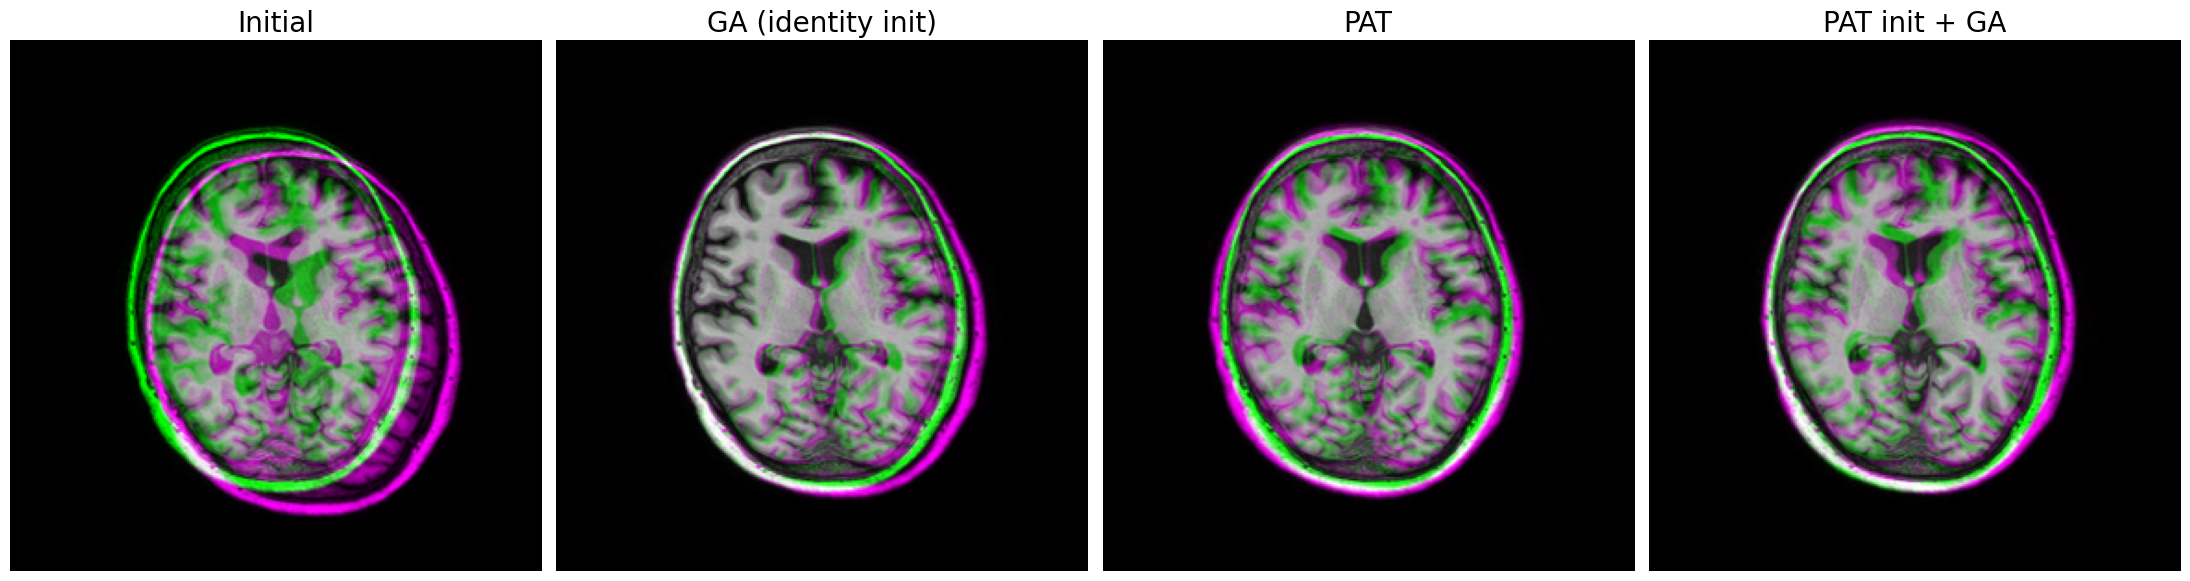

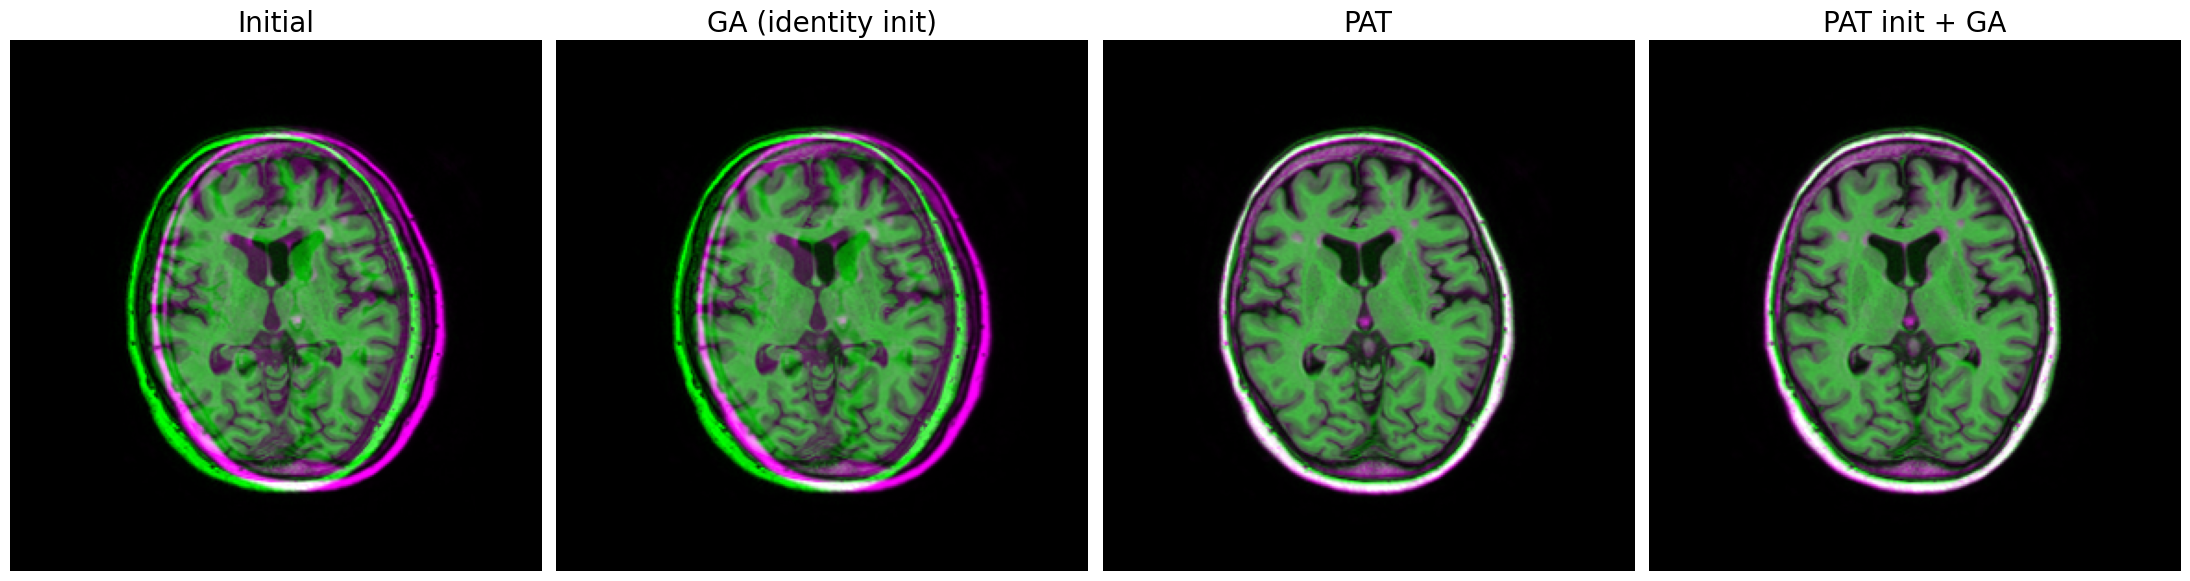

In [78]:
def show_visual_comparison(pair_id):
    pair   = next(p for p in all_pairs if p['pair_id'] == pair_id)
    fixed  = pair['fixed']
    moving = pair['moving']
    J_A    = images_dict[(pair_id, 'A')]
    J_B    = images_dict[(pair_id, 'B')]
    J_C    = images_dict[(pair_id, 'C')]

    diff_before   = pat.color_overlay(fixed,moving)
    diff_A   = pat.color_overlay(fixed, J_A)
    diff_B   = pat.color_overlay(fixed, J_B)
    diff_C   = pat.color_overlay(fixed, J_C) 

    fig, axes = plt.subplots(1, 4, figsize=(22, 10))

    imgs   = [diff_before, diff_A, diff_B, diff_C]
    titles = ['Initial', 'GA (identity init)', 'PAT', 'PAT init + GA']
    for c, (img, title) in enumerate(zip(imgs, titles)):
        axes[c].imshow(img, cmap='gray')
        axes[c].set_title(title, fontsize=20)
        axes[c].axis('off')

    plt.tight_layout()
    plt.show()


show_visual_comparison('P3_S2_T1T1d')
show_visual_comparison('P3_S2_T1T2')

---
## Section 6 — Box plots: similarity metrics after registration

Each box summarises the 9 values (3 patients × 3 slices) for that strategy and modality. The red dashed line marks the pre-registration baseline.

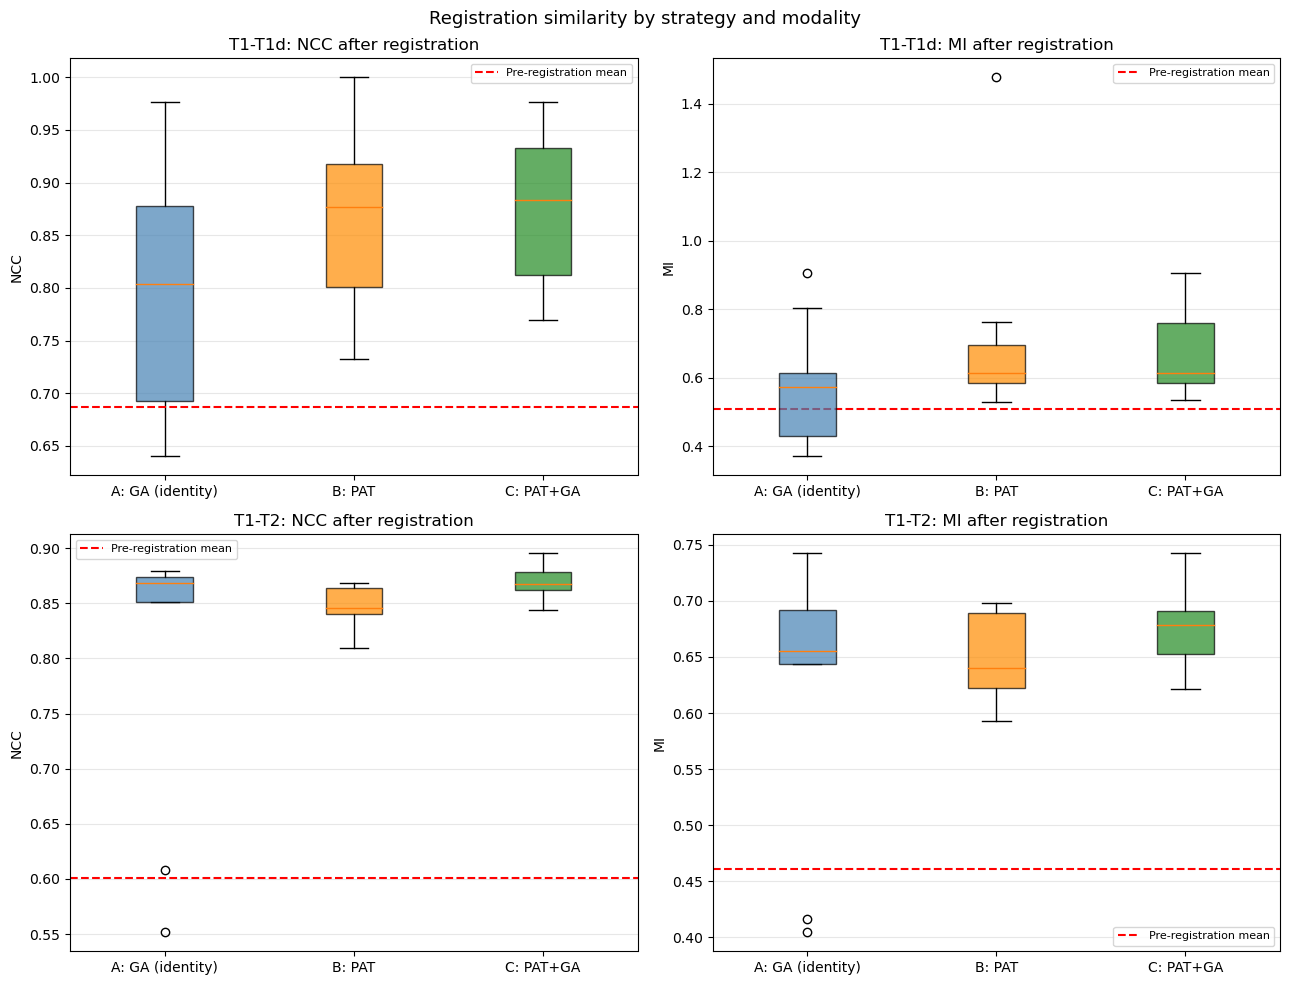

In [79]:
STRAT_COLORS  = {'A': 'steelblue', 'B': 'darkorange', 'C': 'forestgreen'}
STRAT_LABELS  = {'A': 'A: GA (identity)', 'B': 'B: PAT', 'C': 'C: PAT+GA'}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for row_i, (modality, df_mod) in enumerate([
        ('T1-T1d', results_t1t1d), ('T1-T2', results_t1t2)]):
    for col_i, (metric, metric_label) in enumerate([
            ('ncc_after', 'NCC'), ('mi_after', 'MI')]):

        ax   = axes[row_i, col_i]
        data = [df_mod[df_mod.strategy == s][metric].values for s in ['A', 'B', 'C']]
        bp   = ax.boxplot(data, patch_artist=True,
                          labels=[STRAT_LABELS[s] for s in ['A', 'B', 'C']])

        for patch, s in zip(bp['boxes'], ['A', 'B', 'C']):
            patch.set_facecolor(STRAT_COLORS[s])
            patch.set_alpha(0.7)

        baseline = df_mod[df_mod.strategy == 'A'][metric.replace('after', 'before')].mean()
        ax.axhline(baseline, color='red', linestyle='--', lw=1.5,
                   label='Pre-registration mean')

        ax.set_title(f'{modality}: {metric_label} after registration')
        ax.set_ylabel(metric_label)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3, axis='y')

plt.suptitle('Registration similarity by strategy and modality', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 7 — Per-patient analysis

For each patient we compute the **mean NCC after registration** across the 3 slices.

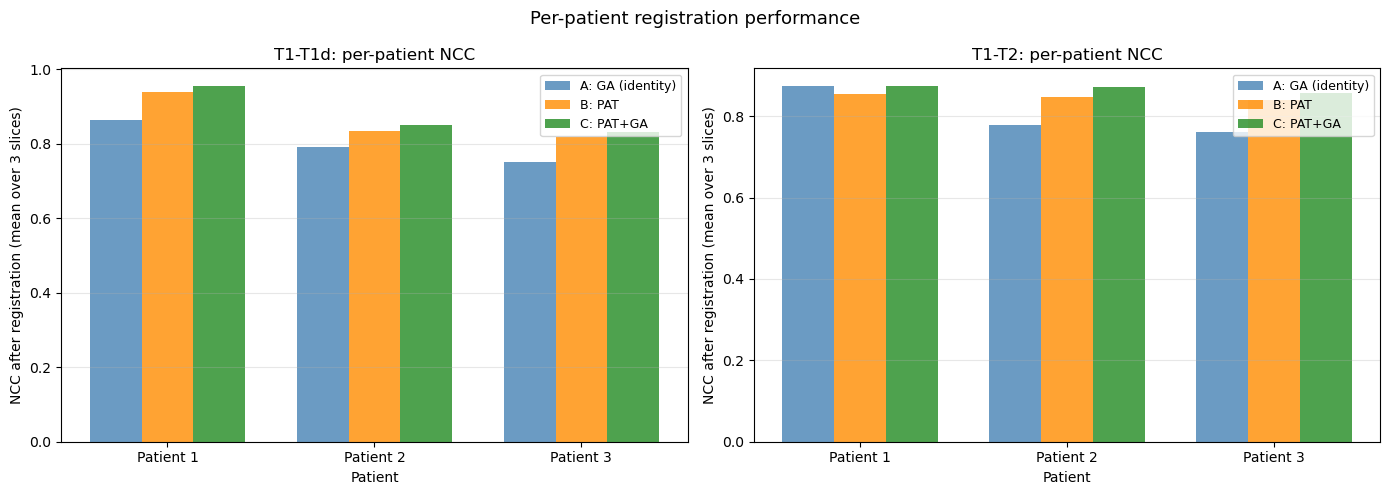

In [80]:
patient_mean = (results
                .groupby(['modality', 'patient_id', 'strategy'])['ncc_after']
                .mean()
                .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_pos = np.arange(len(PATIENTS))
width = 0.25

for col_i, modality in enumerate(['T1-T1d', 'T1-T2']):
    ax    = axes[col_i]
    df_pm = patient_mean[patient_mean.modality == modality]

    for i, strategy in enumerate(['A', 'B', 'C']):
        df_s = df_pm[df_pm.strategy == strategy].sort_values('patient_id')
        ax.bar(x_pos + (i - 1) * width, df_s['ncc_after'].values, width,
               label=STRAT_LABELS[strategy], color=STRAT_COLORS[strategy], alpha=0.8)

    ax.set_xlabel('Patient')
    ax.set_ylabel('NCC after registration (mean over 3 slices)')
    ax.set_title(f'{modality}: per-patient NCC')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'Patient {p}' for p in PATIENTS])
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Per-patient registration performance', fontsize=13)
plt.tight_layout()
plt.show()